# Train Extended Yale B Enhanced Conditions

Notebook nay chi train tu bundle da duoc split truoc. Day la phien ban Yale B da duoc tang cuong preprocessing va loai cac anh qua cuc doan.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent

if not (ROOT / "src").exists():
    raise RuntimeError("Could not locate repo root containing 'src'.")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

ROOT


WindowsPath('D:/HCMUTE_project/Math_for_ML/math_for_ml')

In [2]:
import pandas as pd

from src.process import load_processed_dataset_bundle_for_preset
from src.pipelines import train_pca_knn, train_pca_svm
from src.utils import compare_models, plot_confusion_matrix, plot_explained_variance, save_metrics


c:\Users\phuct\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Training config


In [3]:
config = {
    "dataset_name": "extended_yale_b",
    "preset_name": "enhanced_conditions",
    "role": "enhanced_conditions_20x50",
    "n_components": 20,
    "knn_k": 3,
    "knn_metric": "euclidean",
    "svm_C": 1.0,
    "svm_kernel": "linear",
    "svm_gamma": "scale",
    "svm_max_iter": 50,
}

pd.Series(config)


dataset_name              extended_yale_b
preset_name           enhanced_conditions
role            enhanced_conditions_20x50
n_components                           20
knn_k                                   3
knn_metric                      euclidean
svm_C                                 1.0
svm_kernel                         linear
svm_gamma                           scale
svm_max_iter                           50
dtype: object

## Load pre-split processed bundle


In [4]:
bundle = load_processed_dataset_bundle_for_preset(
    dataset_name=config["dataset_name"],
    preset_name=config["preset_name"],
)

summary = bundle["summary"]
label_names = bundle["metadata"]["label_names"]
confusion_labels = label_names if len(label_names) <= 20 else None

X_train = bundle["X_train"]
X_test = bundle["X_test"]
y_train = bundle["y_train"]
y_test = bundle["y_test"]
test_manifest_path = Path(bundle["output_dir"]) / "manifest_test.csv"

pd.Series({
    "dataset_name": summary["dataset_name"],
    "role": config["role"],
    "samples_total": summary["samples_total"],
    "classes_total": summary["classes_total"],
    "train_shape": summary["train_shape"],
    "test_shape": summary["test_shape"],
    "processing_profile": summary.get("processing_profile"),
    "quality_gate": summary.get("quality_gate"),
    "bundle_dir": bundle["output_dir"],
    "test_manifest": str(test_manifest_path),
    "test_images_raw": len(bundle["test_file_paths"]),
})


dataset_name                                            extended_yale_b
role                                          enhanced_conditions_20x50
samples_total                                                      1000
classes_total                                                        20
train_shape                                                [800, 10304]
test_shape                                                 [200, 10304]
processing_profile                                        yale_b_strong
quality_gate                                              yale_b_strict
bundle_dir            D:\HCMUTE_project\Math_for_ML\math_for_ml\data...
test_manifest         D:\HCMUTE_project\Math_for_ML\math_for_ml\data...
test_images_raw                                                     200
dtype: object

## Train PCA + KNN


In [5]:
knn_model = train_pca_knn(
    X_train,
    y_train,
    n_components=config["n_components"],
    k=config["knn_k"],
    metric=config["knn_metric"],
)

knn_eval = knn_model.evaluate(X_test, y_test)
pd.Series({
    "accuracy": knn_eval["accuracy"],
    "train_time": knn_eval["train_time"],
})


accuracy      0.695000
train_time    0.595717
dtype: float64

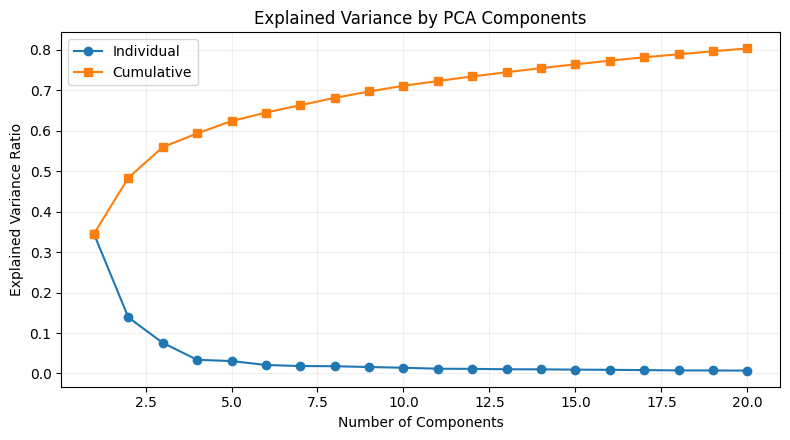

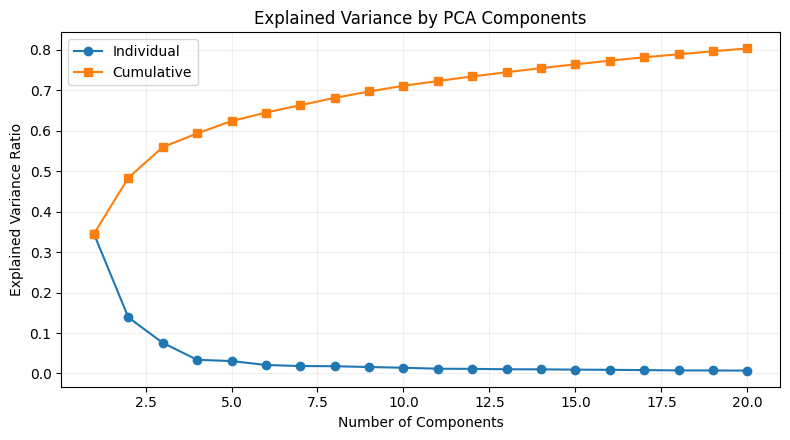

In [6]:
plot_explained_variance(knn_model.pca.explained_variance_ratio_)


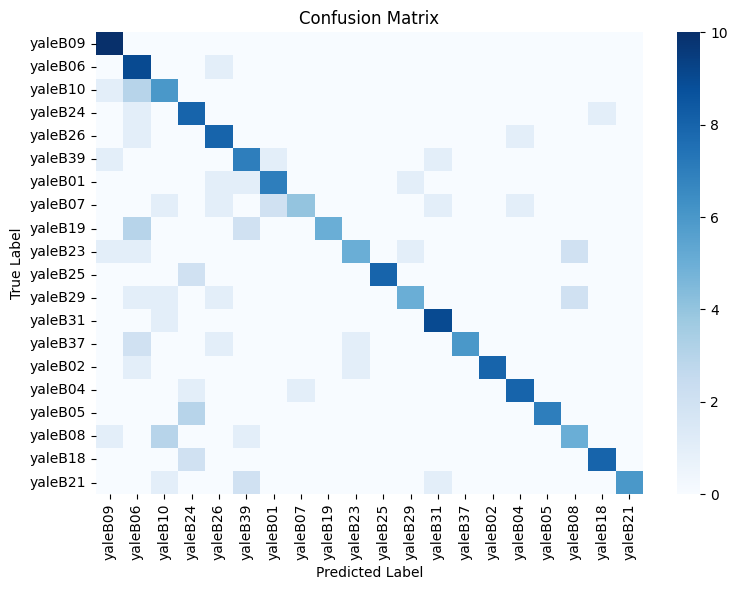

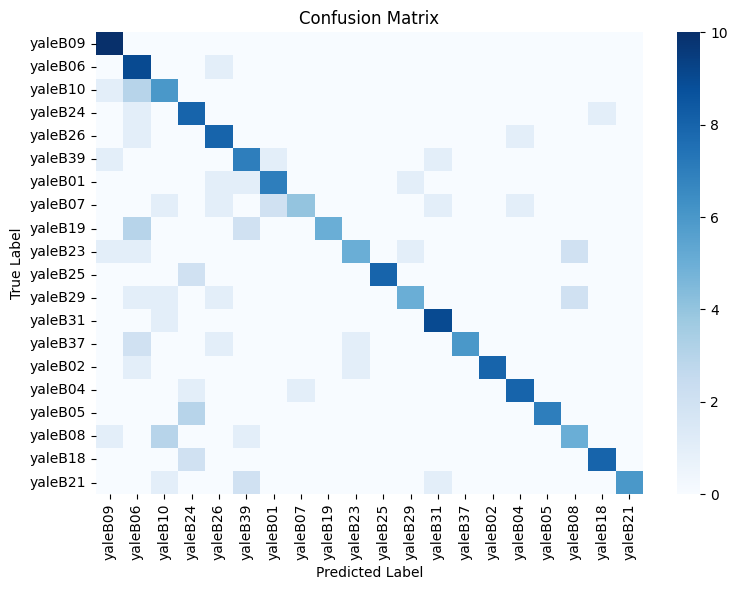

In [7]:
plot_confusion_matrix(knn_eval["confusion_matrix"], labels=confusion_labels)


## Train PCA + SVM


In [8]:
svm_model = train_pca_svm(
    X_train,
    y_train,
    n_components=config["n_components"],
    C=config["svm_C"],
    kernel=config["svm_kernel"],
    gamma=config["svm_gamma"],
    max_iter=config["svm_max_iter"],
)

svm_eval = svm_model.evaluate(X_test, y_test)
pd.Series({
    "accuracy": svm_eval["accuracy"],
    "train_time": svm_eval["train_time"],
})


accuracy      0.885000
train_time    5.281254
dtype: float64

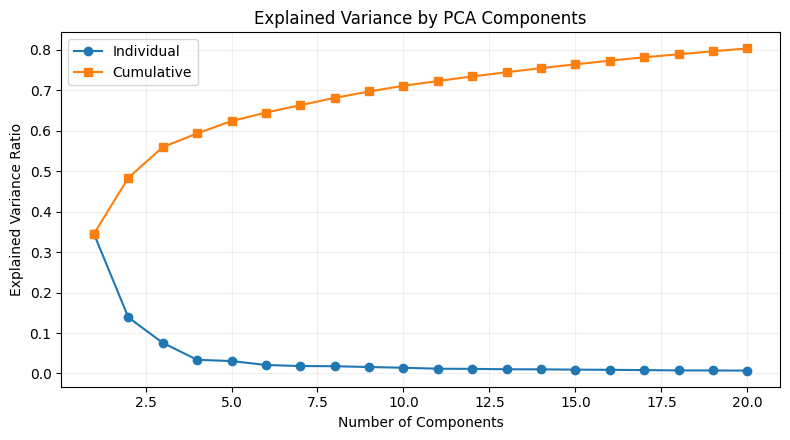

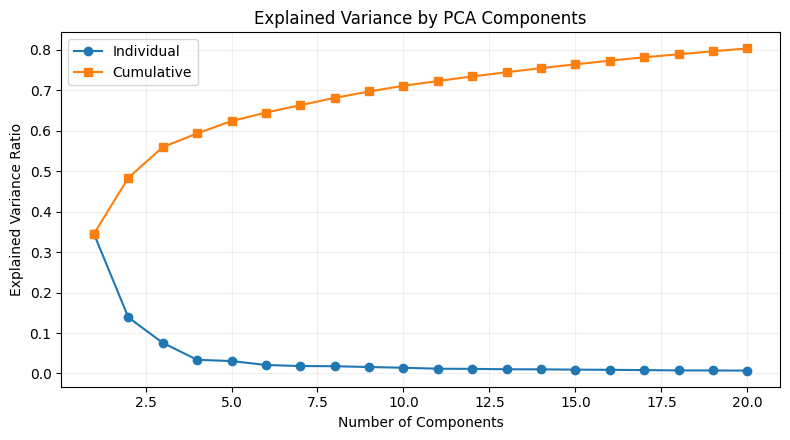

In [9]:
plot_explained_variance(svm_model.pca.explained_variance_ratio_)


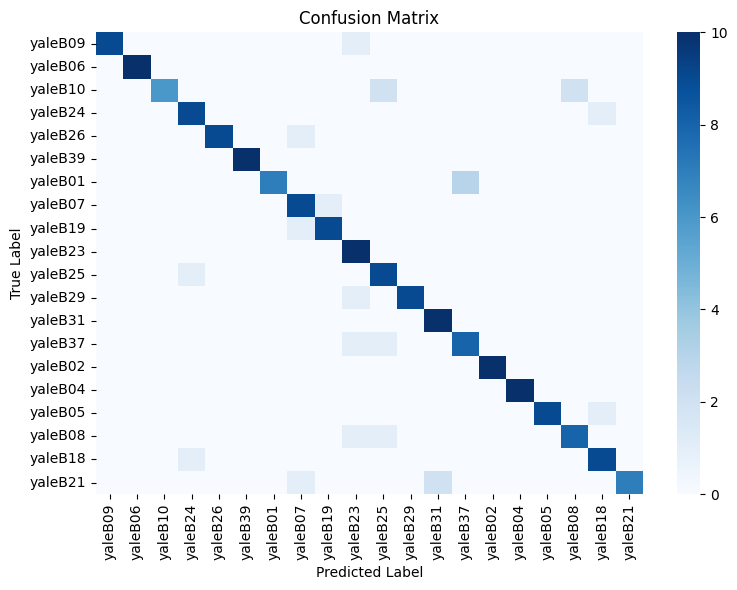

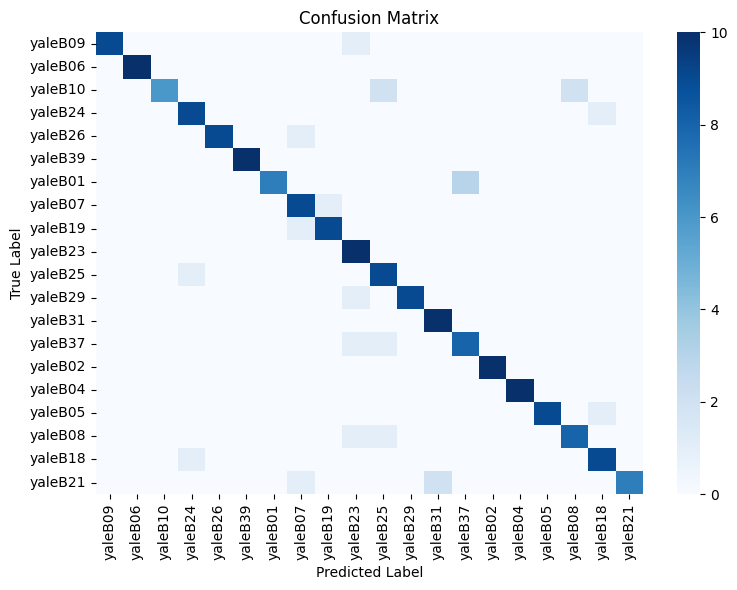

In [10]:
plot_confusion_matrix(svm_eval["confusion_matrix"], labels=confusion_labels)


## Compare and save metrics


In [11]:
comparison_df = compare_models(
    {
        "PCA+KNN": knn_eval,
        "PCA+SVM": svm_eval,
    }
)

comparison_df


         Accuracy  Precision  Recall  F1-Score  Train Time
Model                                                     
PCA+KNN     0.695     0.7581   0.695    0.7001       0.596
PCA+SVM     0.885     0.9027   0.885    0.8853       5.281


,Accuracy,Precision,Recall,F1-Score,Train Time
Model,,,,,
PCA+KNN,0.695,0.7581,0.695,0.7001,0.596
PCA+SVM,0.885,0.9027,0.885,0.8853,5.281


In [12]:
metrics_path = ROOT / "results" / "metrics" / "extended_yale_b_enhanced_conditions_comparison.csv"
save_metrics(comparison_df, metrics_path)
metrics_path


[metrics] Đã lưu: D:\HCMUTE_project\Math_for_ML\math_for_ml\results\metrics\extended_yale_b_enhanced_conditions_comparison.csv


WindowsPath('D:/HCMUTE_project/Math_for_ML/math_for_ml/results/metrics/extended_yale_b_enhanced_conditions_comparison.csv')

## Optional: save trained models


In [13]:
model_dir = ROOT / "webapp" / "saved_models"
model_dir.mkdir(parents=True, exist_ok=True)

knn_path = model_dir / "pca_knn_extended_yale_b_enhanced_conditions.pkl"
svm_path = model_dir / "pca_svm_extended_yale_b_enhanced_conditions.pkl"

knn_model.save_model(knn_path)
svm_model.save_model(svm_path)

pd.Series({
    "knn_model": str(knn_path),
    "svm_model": str(svm_path),
})


knn_model    D:\HCMUTE_project\Math_for_ML\math_for_ml\weba...
svm_model    D:\HCMUTE_project\Math_for_ML\math_for_ml\weba...
dtype: str